## DeepSpot inference from H&E images

Here, we provide an example of how to use the pretrained weights and perform inference using DeepSpot to predict spatial transcriptomics from H&E images.

In [1]:
import os
os.chdir('../../')

Export packages

In [2]:
from deepspot.utils.utils_image import predict_spot_spatial_transcriptomics_from_image_path
from deepspot.utils.utils_image import get_morphology_model_and_preprocess
from deepspot.utils.utils_image import crop_tile

from deepspot.spot import DeepSpot

import matplotlib.image as mpimg
from openslide import open_slide
import matplotlib.pyplot as plt
from tqdm import tqdm
import squidpy as sq
import anndata as ad
import pandas as pd
import numpy as np
import pyvips
import torch
import math
import yaml
import PIL

/scratch2/ig76/sasunih/conda/envs/deepspot/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

Here, we specify the input parameters. This information should be selected carefully, as it is based on the spatial transcriptomics training dataset. We continue with values based on our toy example from the COAD dataset.

In [4]:
out_folder = "example_data"
image_feature_model = 'inception' 
n_mini_tiles = 9 # number of non-overlaping subspots
spot_diameter = 60 # spot diameter
spot_distance = 110 # distance between spots
white_cutoff = 200  # recommended, but feel free to explore
downsample_factor = 10 # downsampling the image used for visualisation in squidpy
model_weights = 'pretrained_model_weights/example_model/weights_Visium.pkl'
model_hparam = 'pretrained_model_weights/example_model/hparam_Visium.yaml'
gene_path = f"{out_folder}/data/info_highly_variable_genes_Visium.csv"
sample = 'ZEN38'
image_path = f'example_data/data/image/{sample}_without_fud.jpg'

In [5]:
genes = pd.read_csv(gene_path)
selected_genes_bool = genes.isPredicted.values
genes_to_predict = genes[selected_genes_bool]
genes_to_predict.sort_values("highly_variable_rank")

,gene_ids,feature_types,genome,mito,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts,n_counts,gene_symbol,gene_name,highly_variable,highly_variable_rank,means,variances,variances_norm,isPredicted
10352,ENSG00000198788,Gene Expression,GRCh38,False,269,26.279070,3.306120,30.490956,10170.0,9.227296,10170.0,MUC2,MUC2,True,0.0,26.279070,5706.393421,12.349738,True
1428,ENSG00000179914,Gene Expression,GRCh38,False,155,8.085271,2.206654,59.948320,3129.0,8.048788,3129.0,ITLN1,ITLN1,True,1.0,8.085271,516.907218,12.049717,True
875,ENSG00000016490,Gene Expression,GRCh38,False,273,23.227390,3.187484,29.457364,8989.0,9.103869,8989.0,CLCA1,CLCA1,True,2.0,23.227390,3957.316035,12.039205,True
8878,ENSG00000122711,Gene Expression,GRCh38,False,271,27.989664,3.366939,29.974160,10832.0,9.290352,10832.0,SPINK4,SPINK4,True,3.0,27.989664,6698.103520,11.985791,True
17287,ENSG00000275395,Gene Expression,GRCh38,False,339,33.271317,3.534309,12.403101,12876.0,9.463198,12876.0,FCGBP,FCGBP,True,4.0,33.271318,7822.094590,11.914602,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4801,ENSG00000145284,Gene Expression,GRCh38,False,16,0.043928,0.042990,95.865633,17.0,2.890372,17.0,SCD5,SCD5,True,4995.0,0.043928,0.047288,1.015241,True
17063,ENSG00000237440,Gene Expression,GRCh38,False,16,0.043928,0.042990,95.865633,17.0,2.890372,17.0,ZNF737,ZNF737,True,4996.0,0.043928,0.047288,1.015241,True
15650,ENSG00000131470,Gene Expression,GRCh38,False,16,0.043928,0.042990,95.865633,17.0,2.890372,17.0,PSMC3IP,PSMC3IP,True,4997.0,0.043928,0.047288,1.015241,True
8641,ENSG00000129295,Gene Expression,GRCh38,False,16,0.043928,0.042990,95.865633,17.0,2.890372,17.0,LRRC6,LRRC6,True,4998.0,0.043928,0.047288,1.015241,True


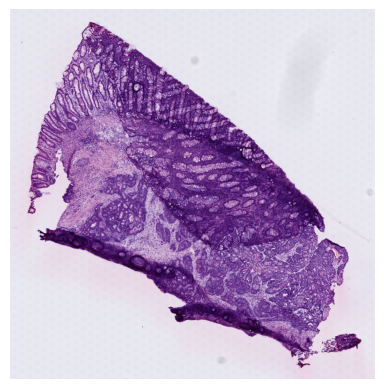

In [6]:
# Load the image
image = mpimg.imread(image_path)

# Display the image
plt.imshow(image)
plt.axis('off')  # Turn off axis labels
plt.show()

We build the grid coordinates for the spots based on the image.

In [7]:
image = pyvips.Image.new_from_file(image_path)

coord = []
for i, x in enumerate(range(spot_diameter + 1, image.height - spot_diameter - 1, spot_distance)):
    for j, y in enumerate(range(spot_diameter + 1, image.width - spot_diameter - 1, spot_distance)):
        coord.append([i, j, x, y])
coord = pd.DataFrame(coord, columns=['x_array', 'y_array', 'x_pixel', 'y_pixel'])
coord.index = coord.index.astype(str)

We select the spots that are located within the tissue.

In [8]:
is_white = []
counts = []
for _, row in tqdm(coord.iterrows()):
    x = row.x_pixel - int(spot_diameter // 2)
    y = row.y_pixel - int(spot_diameter // 2)
    
    main_tile = crop_tile(image, x, y, spot_diameter)
    main_tile = main_tile[:,:,:3]
    white = np.mean(main_tile)
    is_white.append(white)

counts = np.empty((len(is_white), selected_genes_bool.sum())) # empty count matrix 

coord['is_white'] = is_white

1681it [00:01, 1558.47it/s]


We create the anndata object, empty for now

In [9]:
adata = ad.AnnData(counts)
adata.var.index = genes[selected_genes_bool].gene_name.values
adata.obs = adata.obs.merge(coord, left_index=True, right_index=True)
adata.obs['is_white'] = coord['is_white'].values
adata.obs['is_white_bool'] = (coord['is_white'].values > white_cutoff).astype(int)
adata.obs['sampleID'] = sample
adata.obs['barcode'] = adata.obs.index
adata = adata[adata.obs.is_white_bool == 0, ]
adata

View of AnnData object with n_obs × n_vars = 761 × 5000
    obs: 'x_array', 'y_array', 'x_pixel', 'y_pixel', 'is_white', 'is_white_bool', 'sampleID', 'barcode'

In [10]:
### CREATE IMAGE
img = open_slide(image_path)
n_level = len(img.level_dimensions) - 1 # 0 based


large_w, large_h = img.dimensions
new_w = math.floor(large_w / downsample_factor)
new_h = math.floor(large_h / downsample_factor)

whole_slide_image = img.read_region((0, 0), n_level, img.level_dimensions[-1])
whole_slide_image = whole_slide_image.convert("RGB")
img_downsample = whole_slide_image.resize((new_w, new_h), PIL.Image.BILINEAR)


adata.obsm['spatial'] = adata.obs[["y_pixel", "x_pixel"]].values
# adjust coordinates to new image dimensions
adata.obsm['spatial'] = adata.obsm['spatial'] / downsample_factor
# create 'spatial' entries
adata.uns['spatial'] = dict()
adata.uns['spatial']['library_id'] = dict()
adata.uns['spatial']['library_id']['images'] = dict()
adata.uns['spatial']['library_id']['images']['hires'] = np.array(img_downsample)

/tmp/ipykernel_42962/1558753045.py:15: ImplicitModificationWarning: Setting element `.obsm['spatial']` of view, initializing view as actual.
  adata.obsm['spatial'] = adata.obs[["y_pixel", "x_pixel"]].values


In [11]:
# Load the YAML file into a regular Python dictionary
with open(model_hparam, 'r') as yaml_file:
    model_hparam = yaml.safe_load(yaml_file)
model_hparam

{'image_feature_model': 'inception',
 'input_size': 2048,
 'loss_func': 'mse',
 'lr': 0.0001,
 'n_ensemble': 10,
 'n_ensemble_phi': None,
 'n_ensemble_rho': None,
 'output_size': 5000,
 'p': 0.3,
 'p_phi': None,
 'p_rho': None,
 'phi2rho_size': 512,
 'random_seed': 2024,
 'scaler': 'StandardScaler()',
 'spot_context': 'spot_subspot_neighbors',
 'weight_decay': 1e-06}

Initialize DeepSpot and the pretrained pathology foundation model. This time, we compute the tile representation on the fly, which may take more time. The current implementation preprocesses a single spot per batch, but extending it to multiple spots might offer additional speed improvements. Contributions are welcome.

In [13]:
model_expression = torch.load(model_weights, map_location=device, weights_only = False)
model_expression.to(device)
model_expression.eval()

DeepSpot(
  (phi_spot): ModuleList(
    (0-9): 10 x Phi(
      (model): Sequential(
        (0): Linear(in_features=2048, out_features=512, bias=True)
        (1): Dropout(p=0.3, inplace=False)
        (2): ReLU(inplace=True)
      )
    )
  )
  (rho): ModuleList(
    (0-9): 10 x Rho(
      (model): Sequential(
        (0): Dropout(p=0.3, inplace=False)
        (1): ReLU(inplace=True)
        (2): Linear(in_features=1536, out_features=5000, bias=True)
        (3): Dropout(p=0.1, inplace=False)
      )
    )
  )
)

In [14]:
morphology_model, preprocess, feature_dim = get_morphology_model_and_preprocess(model_name=image_feature_model, device=device)
morphology_model.to(device)
morphology_model.eval()

Inception3(
  (Conv2d_1a_3x3): BasicConv2d(
    (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  )
  (Conv2d_2a_3x3): BasicConv2d(
    (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  )
  (Conv2d_2b_3x3): BasicConv2d(
    (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (Conv2d_3b_1x1): BasicConv2d(
    (conv): Conv2d(64, 80, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(80, eps=0.001, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  )
  (Conv2d_4a_3x3): BasicConv2d(
    (con

In [15]:
counts = predict_spot_spatial_transcriptomics_from_image_path(image_path, 
                                                        adata,
                                                        spot_diameter,
                                                        n_mini_tiles,
                                                        preprocess, 
                                                        morphology_model, 
                                                        model_expression, 
                                                        device,
                                                        super_resolution=False,
                                                        neighbor_radius=1)

100%|██████████| 761/761 [01:10<00:00, 10.83it/s]


##### Remember from the training notebook...
The `scaler` is important to be the same as the one used during training, so that the predictions of DeepSpot can be rescaled back to their original ranges using the `inverse_transform` function. 

##### IMPORTANT: Remember to manually rescale the values, as this is not done automatically.
```
expression_norm = model(X)
expression_norm should be np.array
expression = model.inverse_transform(expression_norm)
```

In [16]:
counts = model_expression.inverse_transform(counts)
counts

array([[0.07196, 0.08   , 0.02885, ..., 1.8545 , 5.164  , 0.1046 ],
       [0.071  , 0.0807 , 0.02858, ..., 1.852  , 5.152  , 0.10425],
       [0.0712 , 0.0809 , 0.02896, ..., 1.842  , 5.156  , 0.10455],
       ...,
       [0.0725 , 0.081  , 0.02875, ..., 1.857  , 5.156  , 0.1039 ],
       [0.0724 , 0.0803 , 0.02975, ..., 1.864  , 5.15   , 0.10394],
       [0.0721 , 0.08075, 0.02905, ..., 1.854  , 5.15   , 0.1034 ]],
      shape=(761, 5000), dtype=float16)

You are free to explore other types of transformations that may enhance spatial transcriptomics predictions. The following are just a few examples.

In [17]:
counts[counts < 0] = 0

In [18]:
adata_predicted = ad.AnnData(counts, 
                             var=adata.var,
                             obs=adata.obs, 
                             uns=adata.uns, 
                             obsm=adata.obsm).copy()
adata_predicted

AnnData object with n_obs × n_vars = 761 × 5000
    obs: 'x_array', 'y_array', 'x_pixel', 'y_pixel', 'is_white', 'is_white_bool', 'sampleID', 'barcode'
    uns: 'spatial'
    obsm: 'spatial'

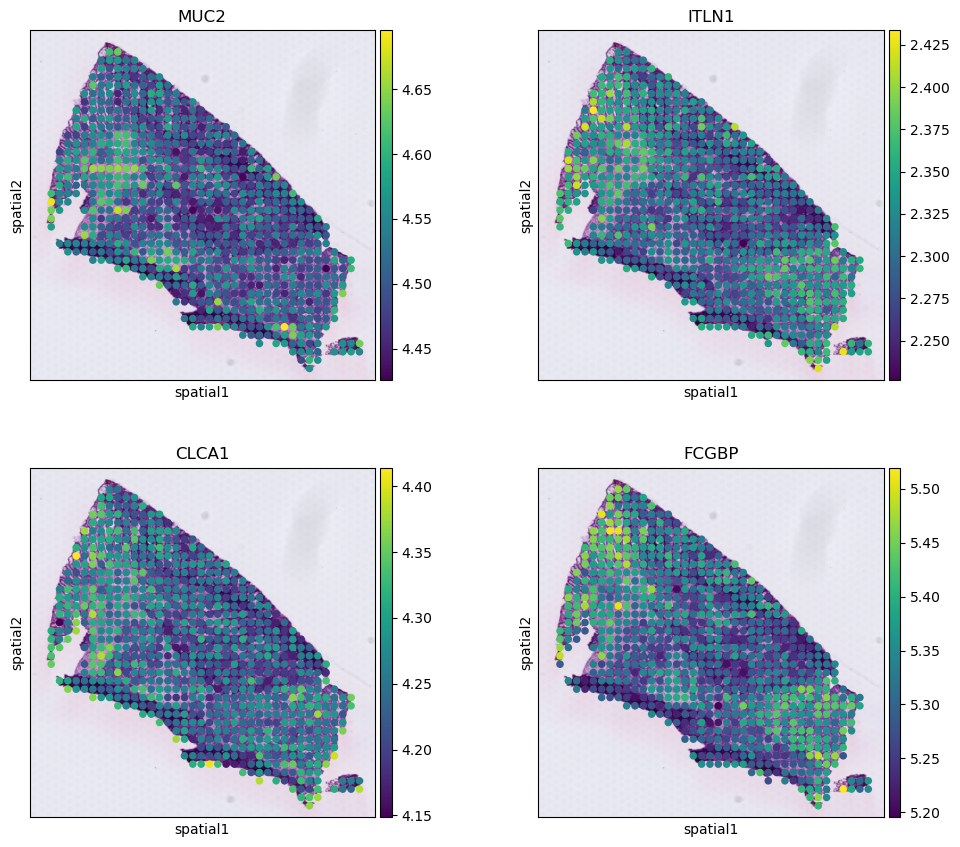

In [19]:
sq.pl.spatial_scatter(adata_predicted, 
                      color=['MUC2', 'ITLN1', 
                             'CLCA1', 'FCGBP'], 
                      wspace=0,
                      ncols=2,
                      size=5)